# Task 2: SQL & Data Extraction

**ApexPlanet Software Pvt. Ltd.**  
**Data Analytics Internship Program 2026**

**Submitted By:** Khushi Vig  
**Domain:** Data Analytics  
**Dataset:** Sample Superstore Dataset

---

## Objective

The objective of this task is to understand how SQL can be used for data extraction, transformation, and analysis within a relational database environment.

The project demonstrates:

- Creating and connecting to a SQLite database
- Importing cleaned datasets into database tables
- Performing data retrieval using SQL queries
- Applying aggregation and filtering techniques
- Using advanced SQL concepts such as CTEs and Window Functions
- Integrating SQL with Python for analytical workflows

## Tools Used

The following tools and technologies were used throughout this project:

- **Python** - data loading, transformation, and orchestration
- **SQLite** - lightweight relational database for storing and querying the dataset
- **SQLAlchemy** - database-agnostic connection layer, demonstrated alongside the native `sqlite3` driver
- **Pandas** - moving query results into DataFrames for further analysis
- **Jupyter Notebook** - combining code, SQL, and explanation in one document
- **SQL** - all data retrieval, filtering, aggregation, and transformation logic

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

os.makedirs('../reports/images', exist_ok=True)


In [2]:
df = pd.read_csv("../data/processed/cleaned_superstore.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%Y-%m-%d")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%Y-%m-%d")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## Creating the SQLite Database

SQLite is used for this project because it is a lightweight, file-based relational database that does not need a separate server to be installed or configured. This makes it a practical choice for a student project, where the focus is on writing and understanding SQL rather than managing database infrastructure.

The cell below creates a connection object, `conn`, which Python uses to send SQL commands to the database and receive results back. This connection stays open for the rest of the notebook and is reused in every query that follows.

In [3]:
conn = sqlite3.connect("superstore.db")

print("Database connection established successfully.")

Database connection established successfully.


## Importing the Dataset into the Database

The cleaned dataset from Task 1 is loaded into a table named **superstore** using `to_sql()`. Setting `if_exists="replace"` means that re-running this cell always overwrites the table with the latest version of the dataframe, which is useful while the notebook is still being developed and tested.

Once this step runs successfully, the data can be queried using standard SQL instead of pandas operations, which is the focus of the rest of this notebook.

In [4]:
df.to_sql(
    "superstore",
    conn,
    if_exists="replace",
    index=False
)

print("Dataset imported successfully")

Dataset imported successfully


## Dataset Overview

This project uses the Sample Superstore dataset, a transactional retail dataset for a fictional superstore business. It contains order-level records covering customers, products, shipping details, sales, discounts and profit.

The dataset was cleaned and prepared during Task 1, including handling missing values, correcting data types and removing outliers. In this task, that cleaned version is loaded into a SQLite database so it can be queried using SQL rather than only through pandas, which mirrors how analysts typically work with data stored in a real database environment.

## Part 1: SQL Fundamentals

This section covers the foundational SQL building blocks: filtering rows, sorting results, limiting output, aggregating values, and combining data with subqueries, CTEs and window functions. These are the queries used most often in everyday data analysis work.

### Query 1: SELECT and LIMIT

`SELECT *` retrieves every column from the superstore table, and `LIMIT 10` restricts the output to the first ten rows. This is typically the first query run against any new table, since it confirms the import worked correctly and gives a quick sense of what the columns and values look like before writing more complex queries.

In [5]:
query = """
SELECT *
FROM superstore
LIMIT 10;
"""

pd.read_sql(query, conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03T00:00:00,2023-01-07T00:00:00,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04T00:00:00,2023-01-08T00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04T00:00:00,2023-01-08T00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04T00:00:00,2023-01-08T00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05T00:00:00,2023-01-12T00:00:00,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
5,6,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,9,0.0,746.4078
6,7,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,OFF-AR-10001662,Office Supplies,Art,Rogers Handheld Barrel Pencil Sharpener,5.480,2,0.0,1.4796
7,8,US-2023-106054,2023-01-06T00:00:00,2023-01-07T00:00:00,First Class,JO-15145,Jack O'Briant,Corporate,United States,Athens,...,30605,South,OFF-AR-10002399,Office Supplies,Art,"Dixon Prang Watercolor Pencils, 10-Color Set w...",12.780,3,0.0,5.2398
8,9,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,609.980,2,0.0,274.4910
9,10,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,OFF-FA-10001883,Office Supplies,Fasteners,"Alliance Super-Size Bands, Assorted Sizes",31.120,4,0.0,0.3112


#### Observation

The ten rows returned confirm the import completed correctly and give an immediate sense of the column names, data types, and value formats before any further query is written. Checking the raw data this way at the start is standard practice to catch import issues early, such as date columns stored as text or unexpected NULL values.

### Query 2: WHERE Clause

The WHERE clause filters rows before they're returned, based on a condition. Here, only orders with `Sales > 1000` are kept, isolating the higher-value transactions from the much larger pool of everyday orders. This is the building block for almost every other query in this notebook; GROUP BY and JOIN both rely on the same filtering logic underneath.


In [6]:
query = """
SELECT *
FROM superstore
WHERE Sales > 1000;
"""

pd.read_sql(query, conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,6,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,9,0.0,746.4078
1,31,US-2023-157147,2023-01-13T00:00:00,2023-01-18T00:00:00,Standard Class,BD-11605,Brian Dahlen,Consumer,United States,San Francisco,...,94109,West,OFF-ST-10000078,Office Supplies,Storage,Tennsco 6- and 18-Compartment Lockers,1325.850,5,0.0,238.6530
2,44,US-2023-147627,2023-01-20T00:00:00,2023-01-26T00:00:00,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Jonesboro,...,72401,South,FUR-CH-10002331,Furniture,Chairs,Hon 4700 Series Mobuis Mid-Back Task Chairs wi...,1067.940,3,0.0,224.2674
3,103,US-2023-127614,2023-02-11T00:00:00,2023-02-15T00:00:00,Standard Class,NF-18385,Natalie Fritzler,Consumer,United States,Chesapeake,...,23320,South,FUR-TA-10003715,Furniture,Tables,Hon 2111 Invitation Series Corner Table,1256.220,6,0.0,75.3732
4,182,US-2023-125521,2023-03-14T00:00:00,2023-03-19T00:00:00,Standard Class,CK-12325,Christine Kargatis,Home Office,United States,Chesapeake,...,23320,South,FUR-CH-10003379,Furniture,Chairs,Global Commerce Series High-Back Swivel/Tilt C...,1139.920,4,0.0,284.9800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,10060,US-2026-138380,2026-12-21T00:00:00,2026-12-25T00:00:00,Standard Class,YS-21880,Yana Sorensen,Corporate,United States,Oakland,...,94601,West,OFF-ST-10003306,Office Supplies,Storage,Letter Size Cart,1000.020,7,0.0,290.0058
466,10067,US-2026-120376,2026-12-22T00:00:00,2026-12-25T00:00:00,First Class,TP-21130,Theone Pippenger,Consumer,United States,Detroit,...,48227,Central,FUR-CH-10002335,Furniture,Chairs,Hon GuestStacker Chair,1586.690,7,0.0,412.5394
467,10121,US-2026-147956,2026-12-24T00:00:00,2026-12-31T00:00:00,Standard Class,AH-10210,Alan Hwang,Consumer,United States,Seattle,...,98105,West,OFF-ST-10001097,Office Supplies,Storage,Office Impressions Heavy Duty Welded Shelving ...,1003.620,6,0.0,0.0000
468,10122,US-2026-145219,2026-12-24T00:00:00,2026-12-25T00:00:00,First Class,RM-19675,Robert Marley,Home Office,United States,Los Angeles,...,90049,West,TEC-CO-10001449,Technology,Copiers,Hewlett Packard LaserJet 3310 Copier,2879.952,6,0.2,1007.9832


#### Observation

Filtering down to orders above 1,000 in sales immediately narrows the focus to high-value transactions, which represent a small fraction of all orders but a disproportionately large share of total revenue. This kind of filter is the starting point for most revenue-concentration analyses.

### Query 3: ORDER BY

ORDER BY sorts the result set; `DESC` puts the largest values first. Combined with `LIMIT 10`, this surfaces the ten single biggest transactions in the entire dataset, useful for spotting outliers or simply seeing what a maximum-value order actually looks like.


In [7]:
query = """
SELECT *
FROM superstore
ORDER BY Sales DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,227,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
1,5895,US-2025-118689,2025-10-02T00:00:00,2025-10-09T00:00:00,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
2,7256,US-2026-140151,2026-03-23T00:00:00,2026-03-25T00:00:00,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
3,9172,US-2026-127180,2026-10-22T00:00:00,2026-10-24T00:00:00,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4,9518,US-2026-166709,2026-11-17T00:00:00,2026-11-22T00:00:00,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
5,6675,US-2025-117121,2025-12-17T00:00:00,2025-12-21T00:00:00,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
6,1204,US-2023-116904,2023-09-23T00:00:00,2023-09-28T00:00:00,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
7,4625,US-2025-107440,2025-04-16T00:00:00,2025-04-20T00:00:00,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8,4283,US-2025-158841,2025-02-02T00:00:00,2025-02-04T00:00:00,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
9,4846,US-2025-143714,2025-05-23T00:00:00,2025-05-27T00:00:00,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


#### Observation

The ten largest single transactions confirm the presence of outliers at the upper end of the sales distribution, which were noted during Task 1 EDA. Seeing them here by name and category provides context for why the average sale is pulled well above the median value, and which product categories tend to generate the biggest individual orders.

### Query 4: Aggregate Functions

Aggregate functions collapse many rows into one summary number. This query reports five of them at once over the whole table:

- `COUNT(*)` - total number of order line items
- `SUM(Sales)` - total revenue across every transaction
- `AVG(Sales)` - the average value of a single transaction
- `MIN(Sales)` / `MAX(Sales)` - the smallest and largest individual sale

Together these five numbers are usually the first thing reported in any sales summary, since they describe the overall scale and spread of the business in one row.


In [8]:
query = """
SELECT
COUNT(*) AS Total_Orders,
SUM(Sales) AS Total_Sales,
AVG(Sales) AS Average_Sales,
MIN(Sales) AS Minimum_Sales,
MAX(Sales) AS Maximum_Sales
FROM superstore;
"""

pd.read_sql(query, conn)

,Total_Orders,Total_Sales,Average_Sales,Minimum_Sales,Maximum_Sales
0,10194,2.326534e+06,228.225854,0.444,22638.48


#### Observation

These five numbers summarise the entire dataset in one row. The gap between the minimum and maximum sale value is very large, confirming the wide spread seen during EDA. The average is significantly higher than a typical transaction would suggest, because a small number of very large orders pull the mean upward, which is exactly why median would be a better central tendency measure for this dataset.

### Query 5: GROUP BY

GROUP BY splits the table into buckets, one per distinct value in the grouping column, and the aggregate function runs separately within each bucket. Here, `SUM(Sales)` is calculated once per `Category`, turning one big total into three category-level totals that can be compared directly.


In [9]:
query = """
SELECT
Category,
SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Category;
"""

pd.read_sql(query, conn)

,Category,Total_Sales
0,Furniture,754747.7613
1,Office Supplies,731893.3140
2,Technology,839893.2790


#### Observation

Breaking the total sales figure down by category immediately shows whether revenue is evenly distributed across the business or concentrated in one area. A category with significantly higher sales than the others would warrant closer attention, both to understand what is driving that volume and to assess whether profitability follows the same pattern.

### Query 6: HAVING Clause

WHERE filters individual rows before grouping; HAVING filters the grouped results after the aggregation has already happened. The distinction matters because `SUM(Sales) > 500000` only makes sense once the sum exists, and a WHERE clause has no way to reference an aggregate that hasn't been computed yet. This query keeps only the categories whose combined sales clear that threshold.


In [10]:
query = """
SELECT
Category,
SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Category
HAVING SUM(Sales) > 500000;
"""

pd.read_sql(query, conn)

,Category,Total_Sales
0,Furniture,754747.7613
1,Office Supplies,731893.3140
2,Technology,839893.2790


#### Observation

HAVING here acts as a post-aggregation threshold, keeping only the categories that cleared half a million in total sales. The categories that are excluded by this filter are not necessarily underperforming on profit, but they did not reach this particular sales volume, which is useful context when setting revenue targets by category.

### Query 7: Subquery

A subquery is a complete SELECT statement nested inside another query, and it runs first so its result can be used by the outer query. Here, the inner query computes one number, the overall average sales value, and the outer query uses that number as the threshold in its own WHERE clause. The effect is a list of every "above average" transaction, without ever hardcoding what "average" means.


In [11]:
query = """
SELECT *
FROM superstore
WHERE Sales >
(
SELECT AVG(Sales)
FROM superstore
);
"""

pd.read_sql(query, conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,4,US-2023-112326,2023-01-04T00:00:00,2023-01-08T00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
1,6,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,9,0.0,746.4078
2,9,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,609.980,2,0.0,274.4910
3,13,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,TEC-PH-10004539,Technology,Phones,Wireless Extenders zBoost YX545 SOHO Signal Bo...,755.960,4,0.0,204.1092
4,14,US-2023-167199,2023-01-06T00:00:00,2023-01-10T00:00:00,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,TEC-PH-10004977,Technology,Phones,GE 30524EE4,391.980,2,0.0,113.6742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2392,10173,US-2026-158526,2026-12-29T00:00:00,2027-01-01T00:00:00,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Louisville,...,40214,South,FUR-CH-10002602,Furniture,Chairs,DMI Arturo Collection Mission-style Design Woo...,1207.840,8,0.0,314.0384
2393,10174,US-2026-118885,2026-12-29T00:00:00,2027-01-02T00:00:00,Standard Class,JG-15160,James Galang,Consumer,United States,Los Angeles,...,90049,West,FUR-CH-10002880,Furniture,Chairs,"Global High-Back Leather Tilter, Burgundy",393.568,4,0.2,-44.2764
2394,10175,US-2026-158526,2026-12-29T00:00:00,2027-01-01T00:00:00,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Louisville,...,40214,South,FUR-CH-10004495,Furniture,Chairs,"Global Leather and Oak Executive Chair, Black",300.980,1,0.0,87.2842
2395,10183,US-2026-118885,2026-12-29T00:00:00,2027-01-02T00:00:00,Standard Class,JG-15160,James Galang,Consumer,United States,Los Angeles,...,90049,West,TEC-PH-10002563,Technology,Phones,Adtran 1202752G1,302.376,3,0.2,22.6782


#### Observation

Using a subquery to calculate the average means the threshold updates automatically if new data is added to the table, instead of requiring the value to be hardcoded and manually updated. The result is a subset of orders that are genuinely above average, not above an arbitrary fixed number, which makes the filter meaningful regardless of when it is run.

### Query 8: Common Table Expression (CTE)

A CTE, introduced with the WITH keyword, creates a named temporary result set that the rest of the query can reference as if it were a table. Here, `CategorySales` stores the total sales per category, and the final SELECT simply reads from it. CTEs do the same job as a subquery but are easier to read and reuse, especially once a query has several steps.

In [12]:
query = """
WITH CategorySales AS
(
SELECT
Category,
SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Category
)

SELECT *
FROM CategorySales;
"""

pd.read_sql(query, conn)

,Category,Total_Sales
0,Furniture,754747.7613
1,Office Supplies,731893.3140
2,Technology,839893.2790


#### Observation

The CTE produces the same result as nesting the aggregation as a subquery inside the final SELECT, but makes the logic significantly easier to follow since the two steps, build the summary, then read from it, are clearly separated. This readability benefit becomes much more important once a query has three or four intermediate steps, where nested subqueries become very difficult to untangle.

### Query 9: ROW_NUMBER()

ROW_NUMBER() is a window function that assigns a unique, increasing number to each row within a defined group, without skipping or repeating numbers even when values tie. PARTITION BY Category restarts the numbering for each category, and ORDER BY Sales DESC means rank 1 is always the highest-selling row in that category. This is useful for tasks like pulling the top N rows per group.

In [13]:
query = """
SELECT
Category,
Sales,
ROW_NUMBER() OVER(
PARTITION BY Category
ORDER BY Sales DESC
) AS Row_Num
FROM superstore;
"""

pd.read_sql(query, conn).head(15)

,Category,Sales,Row_Num
0,Furniture,4416.174,1
1,Furniture,4404.900,2
2,Furniture,4297.644,3
3,Furniture,4228.704,4
4,Furniture,4007.840,5
5,Furniture,3785.292,6
6,Furniture,3610.848,7
7,Furniture,3504.900,8
8,Furniture,3406.664,9
9,Furniture,3393.680,10


#### Observation

ROW_NUMBER() here assigns position 1 to the highest-selling transaction within each category, then counts up from there. Because it never repeats or skips numbers, it can be used to reliably filter to exactly the top N rows per group, for example by wrapping this query in a CTE and then selecting WHERE Row_Num <= 3 to get the top three orders per category.

### Query 10: RANK()

RANK() works like ROW_NUMBER() but handles ties differently: rows with the same Sales value receive the same rank, and the next rank after a tie is skipped accordingly, for example two rows tied at rank 2 means the next row gets rank 4, not 3. This makes RANK() the more accurate choice whenever the underlying values can genuinely be equal, which ROW_NUMBER() would otherwise hide.

In [14]:
query = """
SELECT
Category,
Sales,
RANK() OVER(
PARTITION BY Category
ORDER BY Sales DESC
) AS Sales_Rank
FROM superstore;
"""

pd.read_sql(query, conn).head(15)

,Category,Sales,Sales_Rank
0,Furniture,4416.174,1
1,Furniture,4404.900,2
2,Furniture,4297.644,3
3,Furniture,4228.704,4
4,Furniture,4007.840,5
5,Furniture,3785.292,6
6,Furniture,3610.848,7
7,Furniture,3504.900,8
8,Furniture,3406.664,9
9,Furniture,3393.680,10


#### Observation

RANK() assigns the same number to tied rows, then skips ahead to account for the gap, so two rows tied at rank 2 mean the next distinct value gets rank 4. This gives a more accurate picture of competitive standing than ROW_NUMBER() when values are genuinely equal, which is common in sales data where multiple orders of the same product may share an identical sales figure.

## Part 2: JOIN Operations (Query 11)

The Superstore dataset is a single flat table, so a small reference table, `category_targets`, is created to demonstrate JOIN behaviour properly. It holds a sales target for three categories, including one, Software, that does not exist in the Superstore data, and deliberately leaves out Office Supplies. This means each join type below returns a genuinely different result, which is the entire point of comparing them side by side rather than just defining them.

SQLite supports INNER JOIN and LEFT JOIN natively, but has no RIGHT JOIN or FULL OUTER JOIN keyword. The queries below work around that using a CTE and LEFT JOIN with the table order swapped, and a LEFT JOIN combined with UNION, respectively. Both produce the same logical result a database that does support those keywords would return.


In [15]:
conn.execute("DROP TABLE IF EXISTS category_targets;")

conn.execute("""
CREATE TABLE category_targets (
    Category TEXT,
    Sales_Target REAL
);
""")

conn.execute("""
INSERT INTO category_targets (Category, Sales_Target) VALUES
('Furniture', 250000),
('Technology', 300000),
('Software', 150000);
""")

conn.commit()
print("category_targets table created successfully")

category_targets table created successfully


### INNER JOIN

INNER JOIN keeps only the rows where the join condition matches on both sides. Furniture and Technology appear because both have a row in `category_targets`; Office Supplies is missing because it has no target, and Software is missing because it has no sales. Two unmatched categories on either side simply disappear from the result, which is the defining trait of an inner join.


In [16]:
query = """
SELECT
    cs.Category,
    cs.Total_Sales,
    ct.Sales_Target
FROM (
    SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales
    FROM superstore
    GROUP BY Category
) AS cs
INNER JOIN category_targets AS ct
    ON cs.Category = ct.Category;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Sales_Target
0,Furniture,754747.76,250000.0
1,Technology,839893.28,300000.0


#### Observation

Only Furniture and Technology appear because they are the only categories present in both tables. Office Supplies is dropped because it has no entry in category_targets, and Software is dropped because it has no matching sales records. An INNER JOIN is appropriate when the analysis should only include rows with complete information on both sides.

### LEFT JOIN

LEFT JOIN keeps every row from the left-hand table, the Superstore sales summary, regardless of whether a match exists on the right. Office Supplies appears here with a NULL Sales_Target, since it has sales data but no entry in category_targets.

In [17]:
query = """
SELECT
    cs.Category,
    cs.Total_Sales,
    ct.Sales_Target
FROM (
    SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales
    FROM superstore
    GROUP BY Category
) AS cs
LEFT JOIN category_targets AS ct
    ON cs.Category = ct.Category;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Sales_Target
0,Furniture,754747.76,250000.0
1,Office Supplies,731893.31,NaN
2,Technology,839893.28,300000.0


#### Observation

All three Superstore categories appear here because the left table, the sales summary, is kept in full. Office Supplies shows NULL for Sales_Target since no target was defined for it. A LEFT JOIN is the right choice when the left-side data must be preserved completely and missing reference data should be surfaced rather than silently excluded.

### RIGHT JOIN (SQLite-safe equivalent)

A RIGHT JOIN is the mirror image of a LEFT JOIN: it keeps every row from the right-hand table instead. SQLite has no RIGHT JOIN keyword, so the same result is produced by making `category_targets` the left table in a LEFT JOIN instead, here written as a CTE for clarity. Software now appears with `Total_Sales` as NULL, since it has a target but no actual sales transactions to match against.


In [18]:
query = """
WITH cs AS (
    SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales
    FROM superstore
    GROUP BY Category
)
SELECT
    ct.Category,
    cs.Total_Sales,
    ct.Sales_Target
FROM category_targets AS ct
LEFT JOIN cs
    ON cs.Category = ct.Category;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Sales_Target
0,Furniture,754747.76,250000.0
1,Technology,839893.28,300000.0
2,Software,NaN,150000.0


#### Observation

Software now appears with NULL for Total_Sales because the workaround puts category_targets on the left, preserving every row from it. This is the logical equivalent of a RIGHT JOIN: every target category is retained, and the sales figure is NULL where no matching transactions exist. The approach shows how the same result can be reached without the keyword itself when the database doesn't support it.

### FULL OUTER JOIN (SQLite-safe equivalent)

A FULL OUTER JOIN keeps every row from both tables, matched where possible and NULL on whichever side has no counterpart. SQLite has no FULL OUTER JOIN keyword either, so this is built by running the LEFT JOIN twice, once in each direction, and combining the two result sets with UNION, which automatically removes the duplicate rows that matched in both directions. Office Supplies and Software both appear, each with a NULL on the side they're missing from, while Furniture and Technology appear once with values on both sides.


In [19]:
query = """
WITH cs AS (
    SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales
    FROM superstore
    GROUP BY Category
)
SELECT cs.Category, cs.Total_Sales, ct.Sales_Target
FROM cs
LEFT JOIN category_targets AS ct
    ON cs.Category = ct.Category

UNION

SELECT ct.Category, cs.Total_Sales, ct.Sales_Target
FROM category_targets AS ct
LEFT JOIN cs
    ON cs.Category = ct.Category
WHERE cs.Category IS NULL;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Sales_Target
0,Furniture,754747.76,250000.0
1,Office Supplies,731893.31,NaN
2,Software,NaN,150000.0
3,Technology,839893.28,300000.0


#### Observation

All three Superstore categories appear here because the left table, the sales summary, is kept in full. Office Supplies shows NULL for Sales_Target since no target was defined for it. A LEFT JOIN is the right choice when the left-side data must be preserved completely and missing reference data should be surfaced rather than silently excluded.

## Part 3: Business Queries

With the fundamentals covered, this phase shifts to queries written the way a stakeholder would actually ask for them: not "show me a GROUP BY example" but "which months were strongest" or "who are our best customers." Each query here is followed by a short observation connecting the SQL result back to a business takeaway.


### Query 12: Monthly Sales Trends

`substr([Order Date], 6, 2)` extracts the two-digit month from each date, since Order Date is stored in YYYY-MM-DD format and the month sits at character positions 6 and 7. Grouping by this extracted month and summing Sales gives total revenue for each calendar month across the full date range, which is the basis for spotting seasonal patterns.

In [20]:
query = """
SELECT
    substr([Order Date], 6, 2) AS Month,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM superstore
GROUP BY Month
ORDER BY Month
"""

df_monthly = pd.read_sql(query, conn)
df_monthly

,Month,Total_Sales
0,01,96069.52
1,02,59751.25
2,03,210672.09
3,04,138098.75
4,05,158765.03
5,06,153460.00
6,07,149001.71
7,08,161821.92
8,09,308883.67
9,10,207126.26


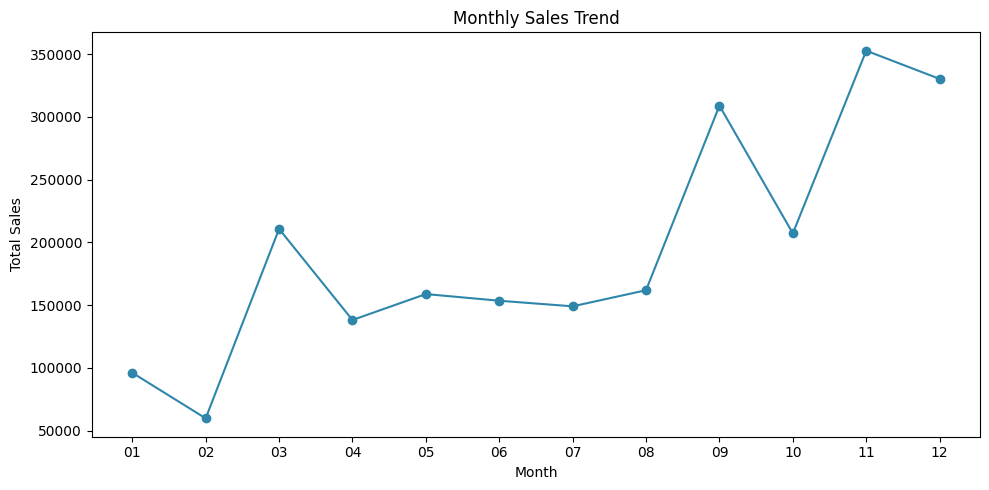

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(df_monthly['Month'], df_monthly['Total_Sales'], marker='o', color='#2E86AB')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../reports/images/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation

Sales are not evenly spread across the year, some months bring in noticeably more revenue than others. A business would use this pattern to plan stock levels and staffing ahead of its busiest periods, rather than treating every month the same.

### Query 13: Top Customers by Revenue

This query sums Sales per customer and returns the ten customers who have generated the most total revenue, sorted highest to lowest. Identifying these customers is a standard first step before any customer segmentation or loyalty programme, since a small group of high-value customers often accounts for a disproportionate share of revenue.

In [22]:
query = """
SELECT
    [Customer Name],
    ROUND(SUM(Sales),2) AS Total_Revenue
FROM superstore
GROUP BY [Customer Name]
ORDER BY Total_Revenue DESC
LIMIT 10;
"""
df_top10 = pd.read_sql(query, conn)
df_top10

,Customer Name,Total_Revenue
0,Sean Miller,25043.05
1,Tamara Chand,19052.22
2,Raymond Buch,15117.34
3,Tom Ashbrook,14595.62
4,Adrian Barton,14473.57
5,Ken Lonsdale,14175.23
6,Sanjit Chand,14142.33
7,Hunter Lopez,12873.30
8,Sanjit Engle,12209.44
9,Christopher Conant,12129.07


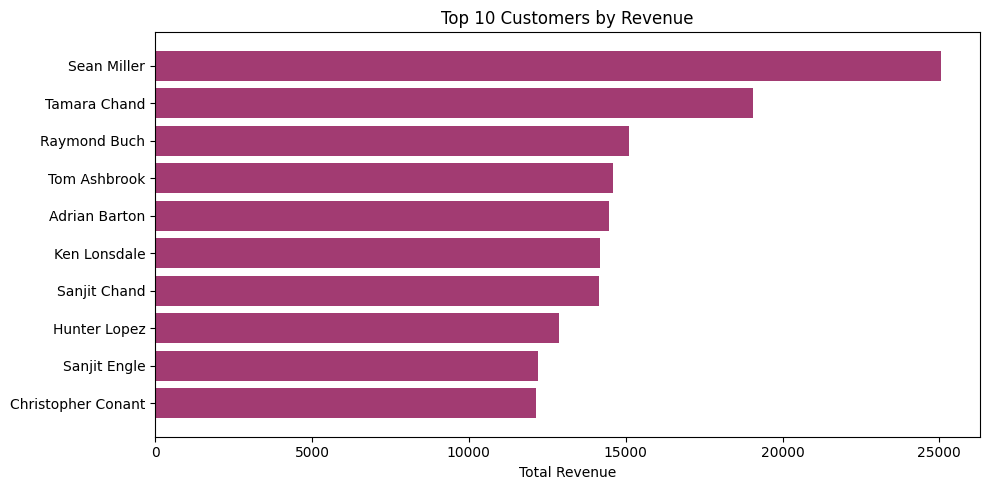

In [23]:
plt.figure(figsize=(10, 5))
plt.barh(df_top10['Customer Name'], df_top10['Total_Revenue'], color='#A23B72')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/images/top10_customers_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation

The customers at the top of this list are the business's most valuable, and losing even one of them would have a measurable impact on revenue. This is exactly the kind of result that would feed into a loyalty programme or account management strategy.

### Query 14: Product Category Performance

This query compares each category on both total sales and total profit, sorted by profit. Looking at the two figures together matters because a category can generate high sales while still being a weak performer on profit, so sales alone would give a misleading picture of which category is actually doing best for the business.

In [24]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales),2) AS Total_Sales,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

df_category = pd.read_sql(query, conn)
df_category


,Category,Total_Sales,Total_Profit
0,Technology,839893.28,146543.38
1,Office Supplies,731893.31,126023.44
2,Furniture,754747.76,19730.00


In [25]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales),2) AS Total_Sales,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

df_category = pd.read_sql(query, conn)
df_category


,Category,Total_Sales,Total_Profit
0,Technology,839893.28,146543.38
1,Office Supplies,731893.31,126023.44
2,Furniture,754747.76,19730.00


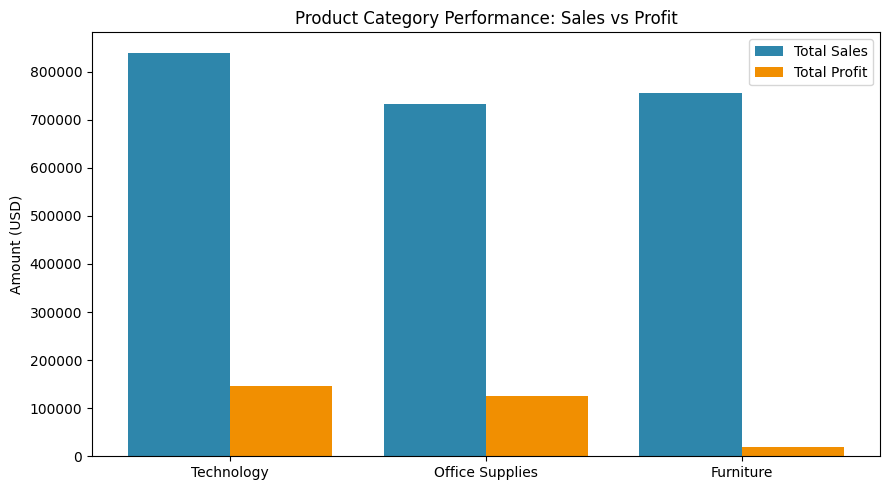

In [26]:
x = range(len(df_category))
plt.figure(figsize=(9, 5))
plt.bar([p - 0.2 for p in x], df_category["Total_Sales"], width=0.4, label="Total Sales", color="#2E86AB", align="center")
plt.bar([p + 0.2 for p in x], df_category["Total_Profit"], width=0.4, label="Total Profit", color="#F18F01", align="center")
plt.xticks(x, df_category["Category"])
plt.title("Product Category Performance: Sales vs Profit")
plt.ylabel("Amount (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/images/category_performance.png", dpi=150, bbox_inches="tight")
plt.show()


#### Observation

Technology leads on both sales and profit in this dataset, which suggests it is the strongest category overall rather than just the highest-selling one. A category that sold well but ranked poorly on profit would be a signal worth investigating, for example through discounting.

### Query 15: Customer Retention Analysis

Repeat purchases are one of the clearest signs of customer loyalty. This query counts the number of distinct orders placed by each customer and keeps only those with more than five orders, identifying the business's most frequent buyers.

In [27]:
query = """
SELECT
    [Customer Name],
    COUNT(DISTINCT [Order ID]) AS Total_Orders
FROM superstore
GROUP BY [Customer Name]
HAVING COUNT(DISTINCT [Order ID]) > 5
ORDER BY Total_Orders DESC;
"""

pd.read_sql(query, conn)

,Customer Name,Total_Orders
0,Emily Phan,17
1,Suzanne McNair,14
2,Eugene Hildebrand,14
3,Bart Pistole,14
4,Zuschuss Carroll,13
...,...,...
466,Anna Andreadi,6
467,Andy Reiter,6
468,Alyssa Tate,6
469,Alex Russell,6


#### Observation

Customers who appear in this list are placing orders regularly rather than buying once and never returning. These repeat buyers are typically more valuable over their lifetime than one-off customers, even if any single order they place isn't the largest in the dataset.

#### Customer Retention Rate

The previous query identifies who the frequent buyers are, but it doesn't say what proportion of the overall customer base they represent. Retention rate answers that directly: it is the percentage of all customers who placed more than one order, regardless of how many orders that was. This gives a single, comparable figure for how well the business is retaining customers, rather than just a list of names.

In [28]:
query = """
WITH CustomerOrders AS (
    SELECT
        [Customer Name],
        COUNT(DISTINCT [Order ID]) AS Total_Orders
    FROM superstore
    GROUP BY [Customer Name]
)
SELECT
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN Total_Orders > 1 THEN 1 ELSE 0 END) AS Repeat_Customers,
    ROUND(
        100.0 * SUM(CASE WHEN Total_Orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2
    ) AS Retention_Rate_Percent
FROM CustomerOrders;
"""

pd.read_sql(query, conn)

,Total_Customers,Repeat_Customers,Retention_Rate_Percent
0,800,788,98.5


#### Observation

A retention rate this high means the overwhelming majority of customers who buy once go on to buy again, which is a strong sign of product satisfaction and a healthy ongoing relationship with the customer base, rather than a business built on constantly acquiring new one-time buyers.


## Part 4: Additional Window Functions

LAG, LEAD, moving averages and cumulative sums all build on the same window function concept introduced earlier with ROW_NUMBER and RANK, but they are used here for time-based comparisons rather than ranking.

### Query 16: LAG()

LAG() looks back at a previous row within the same ordered result set and pulls a value from it into the current row. Here, ordering by Order Date means each row's Previous_Sale column shows the sales value from the transaction immediately before it, which makes row-to-row changes easy to compare without writing a self-join.

In [29]:
query = """
SELECT
    [Order Date],
    Sales,
    LAG(Sales) OVER(
        ORDER BY [Order Date]
    ) AS Previous_Sale
FROM superstore
LIMIT 20;
"""

pd.read_sql(query, conn)

,Order Date,Sales,Previous_Sale
0,2023-01-03T00:00:00,16.448,NaN
1,2023-01-04T00:00:00,3.540,16.448
2,2023-01-04T00:00:00,11.784,3.540
3,2023-01-04T00:00:00,272.736,11.784
4,2023-01-05T00:00:00,19.536,272.736
5,2023-01-06T00:00:00,2573.820,19.536
6,2023-01-06T00:00:00,5.480,2573.820
7,2023-01-06T00:00:00,12.780,5.480
8,2023-01-06T00:00:00,609.980,12.780
9,2023-01-06T00:00:00,31.120,609.980


#### Observation

With the previous sale visible alongside the current one, it becomes straightforward to spot which orders represent a jump or a drop compared to what came right before them, without needing a separate calculation step in pandas.

### Query 17: LEAD()

LEAD() is the mirror image of LAG(): instead of looking backward, it looks forward to the next row in the ordered result set. Next_Sale shows the value of the transaction that comes immediately after the current one, which is useful whenever an analysis needs to compare a value against what happens next rather than what happened before.

In [30]:
query = """
SELECT
    [Order Date],
    Sales,
    LEAD(Sales) OVER(
        ORDER BY [Order Date]
    ) AS Next_Sale
FROM superstore
LIMIT 20;
"""

pd.read_sql(query, conn)

,Order Date,Sales,Next_Sale
0,2023-01-03T00:00:00,16.448,3.540
1,2023-01-04T00:00:00,3.540,11.784
2,2023-01-04T00:00:00,11.784,272.736
3,2023-01-04T00:00:00,272.736,19.536
4,2023-01-05T00:00:00,19.536,2573.820
5,2023-01-06T00:00:00,2573.820,5.480
6,2023-01-06T00:00:00,5.480,12.780
7,2023-01-06T00:00:00,12.780,609.980
8,2023-01-06T00:00:00,609.980,31.120
9,2023-01-06T00:00:00,31.120,6.540


#### Observation

LEAD() makes it straightforward to compare any transaction against the one that follows it chronologically, without needing a self-join or any pandas manipulation after the query runs. This is particularly useful for detecting whether a sale was followed by a larger or smaller transaction, which can help identify short-term momentum patterns in the data.


### Query 18: Moving Average and Cumulative Sum

This query combines two different window frame techniques in one result. `ROWS BETWEEN 6 PRECEDING AND CURRENT ROW` defines a sliding 7-row window, so `Moving_Avg_7` is the average of the current order and the six before it, smoothing out the noise of any single unusually large or small sale. `Cumulative_Sales`, by contrast, has no upper bound on its window, so it's a running total that only ever grows as it moves down the ordered rows.


In [31]:
query = """
SELECT
    [Order Date],
    Sales,
    ROUND(AVG(Sales) OVER (
        ORDER BY [Order Date]
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS Moving_Avg_7,
    ROUND(SUM(Sales) OVER (
        ORDER BY [Order Date]
    ), 2) AS Cumulative_Sales
FROM superstore
LIMIT 20;
"""

pd.read_sql(query, conn)

,Order Date,Sales,Moving_Avg_7,Cumulative_Sales
0,2023-01-03T00:00:00,16.448,16.45,16.45
1,2023-01-04T00:00:00,3.540,9.99,304.51
2,2023-01-04T00:00:00,11.784,10.59,304.51
3,2023-01-04T00:00:00,272.736,76.13,304.51
4,2023-01-05T00:00:00,19.536,64.81,324.04
5,2023-01-06T00:00:00,2573.820,482.98,4731.14
6,2023-01-06T00:00:00,5.480,414.76,4731.14
7,2023-01-06T00:00:00,12.780,414.24,4731.14
8,2023-01-06T00:00:00,609.980,500.87,4731.14
9,2023-01-06T00:00:00,31.120,503.64,4731.14


#### Observation

The moving average line is far smoother than the raw daily sales figures, which makes the underlying trend easier to see without the noise of any single unusually large or small order. The cumulative total is useful for tracking progress toward a revenue target over time.

## Part 5: Views and Query Optimisation

A view saves a query so it can be reused without rewriting it each time, and EXPLAIN QUERY PLAN together with indexing shows how SQLite actually executes a query and how that can be improved.

### Query 19: Creating a View

A view saves a query under a name, so it can be queried again later exactly like a regular table, without retyping or recalculating the underlying logic each time. `CategorySummary` stores the category-level sales and profit totals from earlier in this notebook, which is exactly the kind of query that tends to get re-run constantly during analysis.


In [32]:
conn.execute("""
CREATE VIEW IF NOT EXISTS CategorySummary AS
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Category;
""")

print("View created successfully")

View created successfully


### Retrieve Data from the View

Once created, the view behaves exactly like any other table in the database. Querying it is a plain `SELECT *`, with no GROUP BY or aggregation logic repeated, since all of that is already baked into the view's definition.


In [33]:
query = """
SELECT *
FROM CategorySummary;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Total_Profit
0,Furniture,754747.7613,19729.9956
1,Office Supplies,731893.3140,126023.4434
2,Technology,839893.2790,146543.3756


#### Observation

The view returns the same result as writing the full GROUP BY query from scratch, but using a single short SELECT. Once a view exists, any analyst or downstream query can reference CategorySummary without knowing or rewriting the aggregation logic behind it. This is particularly useful for queries that are rerun frequently, as changes to the underlying logic only need to be made in one place.

The last phase covers two things that matter once a query moves from a notebook into a real workflow: making sure it runs efficiently at scale, and connecting to the database the way an application or script actually would, rather than through a single hardcoded connection object.


### Query 20: Query Optimisation with EXPLAIN QUERY PLAN

EXPLAIN QUERY PLAN doesn't return any data itself, instead it shows how SQLite intends to execute a given query. Run before any index is added, it confirms that finding a single customer's records currently means scanning every row in the superstore table one by one, since there's nothing yet telling SQLite where to look directly.

In [34]:
query = """
EXPLAIN QUERY PLAN
SELECT * FROM superstore WHERE [Customer Name] = 'Sean Miller';
"""

pd.read_sql(query, conn)

,id,parent,notused,detail
0,2,0,0,SCAN TABLE superstore


#### Creating an Index

CREATE INDEX builds a separate lookup structure on the Customer Name column, similar to an index at the back of a book. Instead of scanning the whole table, SQLite can use this structure to jump straight to the matching rows.

In [35]:
conn.execute("CREATE INDEX IF NOT EXISTS idx_customer_name ON superstore([Customer Name]);")
conn.commit()
print("Index created successfully")

Index created successfully


In [36]:
query = """
EXPLAIN QUERY PLAN
SELECT * FROM superstore WHERE [Customer Name] = 'Sean Miller';
"""

pd.read_sql(query, conn)

,id,parent,notused,detail
0,3,0,0,SEARCH TABLE superstore USING INDEX idx_custom...


#### Observation

Re-running EXPLAIN QUERY PLAN after the index is created shows the plan change from a SCAN to a SEARCH using the new index. On a dataset this size the actual speed difference is barely noticeable, but the same indexing principle becomes important once a table grows into the millions of rows, where a full scan would be far too slow for routine queries.

## Part 6: Python and SQL Integration

Every query so far has already been run from Python via `pd.read_sql()`, but a few specific patterns deserve their own walkthrough: pulling a query result into a DataFrame for further analysis, protecting against SQL injection with parameterised queries, connecting through SQLAlchemy instead of the native driver, and exporting every query in this notebook to a standalone file.


### Example 1: Execute a SQL Query from Python

The query result lands directly in a Pandas DataFrame, `sales_df`, which means it's no longer just a SQL result, it's now a regular Python object that can be reshaped, merged, or visualised using anything in the Pandas or wider Python ecosystem.


In [37]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Category;
"""

sales_df = pd.read_sql(query, conn)

sales_df

,Category,Total_Sales
0,Furniture,754747.7613
1,Office Supplies,731893.3140
2,Technology,839893.2790


#### Observation

Once the query result is stored in a DataFrame, the full pandas API is available: filtering rows, renaming columns, merging with other DataFrames, plotting, or exporting to CSV. SQL retrieves and shapes the data efficiently at the database level, and pandas handles everything that is easier to express in Python, which is the standard division of responsibility in a Python-based analytics workflow.


### Example 2: Extending SQL Results with Pandas

Once a query's result is sitting in a DataFrame, it can be extended with calculations that would be more awkward to express in SQL. Here, a new Sales_Percentage column is added showing what share of total sales each category represents, calculated directly in pandas using the totals already retrieved from the database.

In [38]:
sales_df["Sales_Percentage"] = (
    sales_df["Total_Sales"]
    /
    sales_df["Total_Sales"].sum()
) * 100

sales_df

,Category,Total_Sales,Sales_Percentage
0,Furniture,754747.7613,32.440860
1,Office Supplies,731893.3140,31.458522
2,Technology,839893.2790,36.100618


#### Observation

Adding Sales_Percentage directly in pandas is simpler than calculating it in SQL, where it would require a subquery or a window function to access the total. This illustrates a practical rule of thumb: use SQL for set-based operations where the database is efficient, joins, filters, aggregations, and use Python for calculations that depend on the result set as a whole.

### Query 21: Parameterised Query

Every other query in this notebook has used fixed, hardcoded values written directly into the SQL string. Building a query this way with a variable instead, for example inserting a customer name typed in by a user, creates a SQL injection risk if that value is concatenated directly into the string. Using a placeholder, `?`, and passing the value separately through the params argument keeps the data and the query structure separate, which is the safe way to write a query whenever any part of it comes from outside the program.

In [39]:
customer_name = "Sean Miller"

query = """
SELECT *
FROM superstore
WHERE [Customer Name] = ?
"""

pd.read_sql(query, conn, params=(customer_name,))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,219,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,FUR-FU-10001986,Furniture,Furnishings,"Dana Fluorescent Magnifying Lamp, White, 36""",122.352,3,0.2,15.2940
1,220,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,FUR-FU-10004270,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",30.768,2,0.2,8.0766
2,222,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,OFF-AR-10003183,Office Supplies,Art,Avery Fluorescent Highlighter Four-Color Set,8.016,3,0.2,1.0020
3,223,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,OFF-FA-10003112,Office Supplies,Fasteners,Staples,18.936,3,0.2,5.9175
4,224,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,OFF-PA-10001804,Office Supplies,Paper,Xerox 195,21.376,4,0.2,7.4816
5,227,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6,228,US-2023-145317,2023-03-18T00:00:00,2023-03-23T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10003626,Technology,Machines,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,821.300,4,0.5,-16.4260
7,3006,US-2024-130512,2024-08-21T00:00:00,2024-08-25T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Allentown,...,18103,East,OFF-BI-10004519,Office Supplies,Binders,GBC DocuBind P100 Manual Binding Machine,99.588,2,0.7,-82.9900
8,3009,US-2024-130512,2024-08-21T00:00:00,2024-08-25T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Allentown,...,18103,East,OFF-PA-10003625,Office Supplies,Paper,Xerox 1979,49.568,2,0.2,15.4900
9,3012,US-2024-130512,2024-08-21T00:00:00,2024-08-25T00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Allentown,...,18103,East,OFF-ST-10002574,Office Supplies,Storage,"SAFCO Commercial Wire Shelving, Black",663.072,6,0.2,-165.7680


#### Observation

The ? placeholder keeps the query structure and the user-supplied value completely separate at the driver level. If customer_name were instead concatenated directly into the SQL string using an f-string or format(), a malicious value could close the original query early and inject a second one, which is a SQL injection vulnerability. Using params is the correct approach whenever any part of a query comes from outside the program, regardless of whether the source is trusted.

### Query 22: Connecting via SQLAlchemy

sqlite3 has worked fine for this entire notebook because the database is a single local file, but it only works with SQLite. SQLAlchemy provides a connection interface that works the same way across SQLite, PostgreSQL and MySQL, so if this project ever moved to a different database engine, the query and connection code here would barely need to change. The engine created below is used exactly like the sqlite3 connection was, just passed into pd.read_sql() instead of conn.

> **Note:** SQLAlchemy is required for the next cell. If it is not already installed in your environment, run `pip install sqlalchemy` in a terminal before continuing.

In [40]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///superstore.db")

query = """
SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales
FROM superstore
GROUP BY Category;
"""

pd.read_sql(query, engine)

,Category,Total_Sales
0,Furniture,754747.76
1,Office Supplies,731893.31
2,Technology,839893.28


#### Observation

The result matches the equivalent query run through `conn` earlier in this notebook, which is exactly the point: from the perspective of `pd.read_sql()`, a SQLAlchemy engine and a raw `sqlite3` connection are interchangeable. The only thing that changed was how the connection itself was created.


## Part 7: Exporting Queries to a Standalone SQL File

The project deliverables ask for a separate .sql file alongside the notebook, not just queries embedded in markdown and code cells. This final step writes every query used above into a single queries.sql file with a short comment above each one, so the SQL can be reviewed or reused outside of Jupyter entirely.

In [41]:
queries = {
    "01_select_limit": "SELECT * FROM superstore LIMIT 10;",
    "02_where": "SELECT * FROM superstore WHERE Sales > 1000;",
    "03_order_by": "SELECT * FROM superstore ORDER BY Sales DESC LIMIT 10;",
    "04_aggregate_functions": "SELECT COUNT(*) AS Total_Orders, SUM(Sales) AS Total_Sales, AVG(Sales) AS Average_Sales, MIN(Sales) AS Minimum_Sales, MAX(Sales) AS Maximum_Sales FROM superstore;",
    "05_group_by": "SELECT Category, SUM(Sales) AS Total_Sales FROM superstore GROUP BY Category;",
    "06_having": "SELECT Category, SUM(Sales) AS Total_Sales FROM superstore GROUP BY Category HAVING SUM(Sales) > 500000;",
    "07_subquery": "SELECT * FROM superstore WHERE Sales > (SELECT AVG(Sales) FROM superstore);",
    "08_cte": "WITH CategorySales AS (SELECT Category, SUM(Sales) AS Total_Sales FROM superstore GROUP BY Category) SELECT * FROM CategorySales;",
    "09_row_number": "SELECT Category, Sales, ROW_NUMBER() OVER(PARTITION BY Category ORDER BY Sales DESC) AS Row_Num FROM superstore;",
    "10_rank": "SELECT Category, Sales, RANK() OVER(PARTITION BY Category ORDER BY Sales DESC) AS Sales_Rank FROM superstore;",
    "11a_inner_join": "SELECT cs.Category, cs.Total_Sales, ct.Sales_Target FROM (SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales FROM superstore GROUP BY Category) AS cs INNER JOIN category_targets AS ct ON cs.Category = ct.Category;",
    "11b_left_join": "SELECT cs.Category, cs.Total_Sales, ct.Sales_Target FROM (SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales FROM superstore GROUP BY Category) AS cs LEFT JOIN category_targets AS ct ON cs.Category = ct.Category;",
    "11c_right_join": "SELECT cs.Category, cs.Total_Sales, ct.Sales_Target FROM (SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales FROM superstore GROUP BY Category) AS cs RIGHT JOIN category_targets AS ct ON cs.Category = ct.Category;",
    "11d_full_outer_join": "SELECT cs.Category, cs.Total_Sales, ct.Sales_Target FROM (SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales FROM superstore GROUP BY Category) AS cs FULL OUTER JOIN category_targets AS ct ON cs.Category = ct.Category;",
    "12_monthly_sales_trends": "SELECT substr([Order Date], 6, 2) AS Month, ROUND(SUM(Sales),2) AS Total_Sales FROM superstore GROUP BY Month ORDER BY Month;",
    "13_top_customers": "SELECT [Customer Name], ROUND(SUM(Sales),2) AS Total_Revenue FROM superstore GROUP BY [Customer Name] ORDER BY Total_Revenue DESC LIMIT 10;",
    "14_category_performance": "SELECT Category, ROUND(SUM(Sales),2) AS Total_Sales, ROUND(SUM(Profit),2) AS Total_Profit FROM superstore GROUP BY Category ORDER BY Total_Profit DESC;",
    "15a_frequent_buyers": "SELECT [Customer Name], COUNT(DISTINCT [Order ID]) AS Total_Orders FROM superstore GROUP BY [Customer Name] HAVING COUNT(DISTINCT [Order ID]) > 5 ORDER BY Total_Orders DESC;",
    "15b_retention_rate": "WITH CustomerOrders AS (SELECT [Customer Name], COUNT(DISTINCT [Order ID]) AS Total_Orders FROM superstore GROUP BY [Customer Name]) SELECT COUNT(*) AS Total_Customers, SUM(CASE WHEN Total_Orders > 1 THEN 1 ELSE 0 END) AS Repeat_Customers, ROUND(100.0 * SUM(CASE WHEN Total_Orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS Retention_Rate_Percent FROM CustomerOrders;",
    "16_lag": "SELECT [Order Date], Sales, LAG(Sales) OVER(ORDER BY [Order Date]) AS Previous_Sale FROM superstore LIMIT 20;",
    "17_lead": "SELECT [Order Date], Sales, LEAD(Sales) OVER(ORDER BY [Order Date]) AS Next_Sale FROM superstore LIMIT 20;",
    "18_moving_avg_cumulative_sum": "SELECT [Order Date], Sales, ROUND(AVG(Sales) OVER (ORDER BY [Order Date] ROWS BETWEEN 6 PRECEDING AND CURRENT ROW), 2) AS Moving_Avg_7, ROUND(SUM(Sales) OVER (ORDER BY [Order Date]), 2) AS Cumulative_Sales FROM superstore LIMIT 20;",
    "19_create_view": "CREATE VIEW IF NOT EXISTS CategorySummary AS SELECT Category, SUM(Sales) AS Total_Sales, SUM(Profit) AS Total_Profit FROM superstore GROUP BY Category;",
    "20_explain_query_plan": "EXPLAIN QUERY PLAN SELECT * FROM superstore WHERE [Customer Name] = 'Sean Miller';",
    "21_parameterised_query": "SELECT * FROM superstore WHERE [Customer Name] = ?",
}

with open("queries.sql", "w") as f:
    for name, q in queries.items():
        f.write(f"-- {name}\n{q.strip()}\n\n")

print("queries.sql exported successfully")

queries.sql exported successfully


## Key Learnings

Through this task, I gained hands-on experience in working with SQL databases and performing data extraction using Python.

Major concepts covered during this project include:

- Creating and connecting to SQLite databases
- Importing datasets into database tables
- Filtering and sorting records using SQL
- Applying aggregate functions for business reporting
- Using GROUP BY and HAVING clauses
- Writing Subqueries and Common Table Expressions (CTEs)
- Performing INNER, LEFT, RIGHT, and FULL OUTER JOINs
- Working with Window Functions such as ROW_NUMBER(), RANK(), LAG(), and LEAD()
- Calculating moving averages and cumulative sums
- Calculating a customer retention rate alongside frequent-buyer analysis
- Creating reusable Views
- Optimising queries using EXPLAIN QUERY PLAN and indexing
- Executing SQL queries directly from Python using sqlite3 and SQLAlchemy
- Using parameterised queries for secure database interactions
- Exporting all queries to a standalone .sql file

This task helped me understand how SQL and Python work together in real-world data analytics workflows.